## Simulation studies of the Stewart model of pH balance

The polynomial expression for $[H_3O^+]$ is:
$$
[H_3O^+]^4 + (SID + K_a) [H_3O^+]^3 
+ \Big( K_a (SID - A_{\rm tot}) - K_w - K_c \, pCO_2 \Big) [H_3O^+]^2 
- \Big( K_a (K_w + K_c \, pCO_2) - K_3 K_c \, pCO_2 \Big) [H_3O^+] 
- K_a K_3 K_c \, pCO_2 = 0
$$

Let's simulate a few scenarios of this.

### Simulation 1: Influences of the independent variables on H3O+, OH- and pH

In [27]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

In [28]:
# =========================
# Stewart 1983 model simulation (blood plasma)
# =========================

# Physiologic temperature of T = 37 C is used as reference

# --- Equilibrium constants ---
K_w = 4.4e-14        # Water dissociation (equiv/L)^2
K_a = 3e-7           # Weak acids (equiv/L)
K_c = 2.46e-11       # CO2 hydration ((equiv/L)^2 / mmHg)
K_3 = 6e-11          # Carbonate equilibrium (equiv/L)

# --- Independent variables (normative plasma) ---
pCO2  = 40           # mmHg
A_tot = 19e-3        # Total weak acids (equiv/L, 19 mEq/L)
SID   = 42e-3        # Strong ion difference (equiv/L, 42 mEq/L)

In [29]:
# --- Define the quartic polynomial (Stewart 1983 units) ---
def stewart_quartic(H, SID, pCO2, A_tot):
    """
    H: [H3O+] in equiv/L
    SID: strong ion difference (equiv/L)
    pCO2: partial pressure of CO2 (mmHg)
    A_tot: total weak acids (equiv/L)
    """
    term1 = H**4
    term2 = (SID + K_a) * H**3
    term3 = (K_a * (SID - A_tot) - K_w - K_c * pCO2) * H**2
    term4 = -(K_a * (K_w + K_c * pCO2) - K_3 * K_c * pCO2) * H
    term5 = -K_a * K_3 * K_c * pCO2
    return term1 + term2 + term3 + term4 + term5

In [30]:
# --- Solve for [H3O+] ---
H_initial = 4e-8  # near physiologic pH of 7.4
H_solution, = fsolve(stewart_quartic, H_initial, args=(SID, pCO2, A_tot))

# --- Convert to pH ---
pH = -np.log10(H_solution)

# --- Calculate [OH-] ---
OH_solution = K_w / H_solution

print(f"[H3O+] = {H_solution:.3e} equiv/L")
print(f"[OH-]  = {OH_solution:.3e} equiv/L")
print(f"pH     = {pH:.3f}")

[H3O+] = 3.911e-08 equiv/L
[OH-]  = 1.125e-06 equiv/L
pH     = 7.408


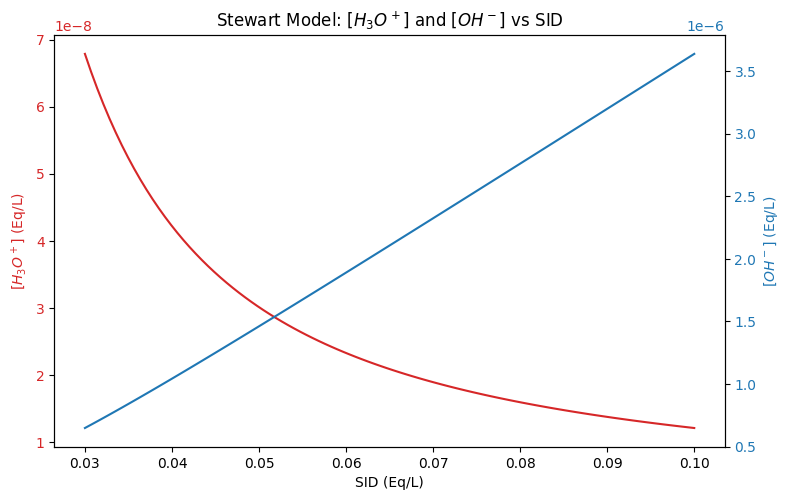

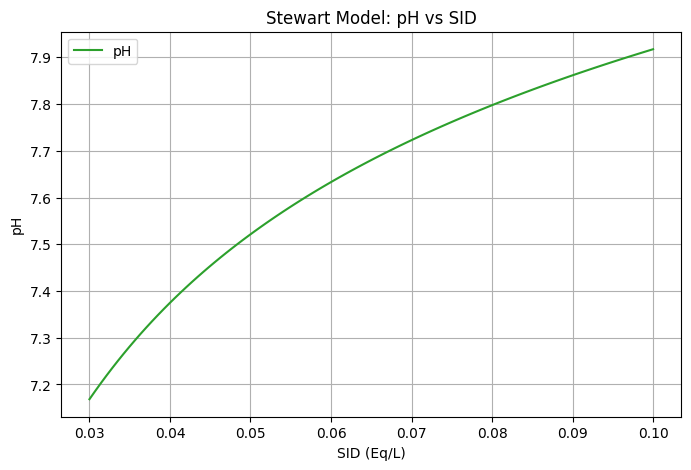

In [8]:
# --- Section 1: Vary SID ---
pCO2 = 40  # mmHg
A_tot = 19e-3  # Eq/L (19 mEq/L)
SID_values = np.linspace(30e-3, 100e-3, 100)  # 30–100 mEq/L

H_initial = 4e-8  # near physiologic pH of 7.4

H3O_values, OH_values, pH_values = [], [], []
for SID in SID_values:
    H_solution, = fsolve(stewart_quartic, H_initial, args=(SID, pCO2, A_tot))
    OH_solution = K_w / H_solution
    pH = -np.log10(H_solution)
    H3O_values.append(H_solution)
    OH_values.append(OH_solution)
    pH_values.append(pH)

# --- Plot: [H3O+] & [OH-] vs SID ---
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(SID_values, H3O_values, color='tab:red', label='$[H_3O^+]$')
ax1.set_xlabel('SID (Eq/L)')
ax1.set_ylabel('$[H_3O^+]$ (Eq/L)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2 = ax1.twinx()
ax2.plot(SID_values, OH_values, color='tab:blue', label='$[OH^-]$')
ax2.set_ylabel('$[OH^-]$ (Eq/L)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
fig.tight_layout()
plt.title("Stewart Model: $[H_3O^+]$ and $[OH^-]$ vs SID")
plt.show()

# --- Plot: pH vs SID ---
plt.figure(figsize=(8,5))
plt.plot(SID_values, pH_values, color='tab:green', label='pH')
plt.xlabel('SID (Eq/L)')
plt.ylabel('pH')
plt.title("Stewart Model: pH vs SID")
plt.grid(True)
plt.legend()
plt.show()

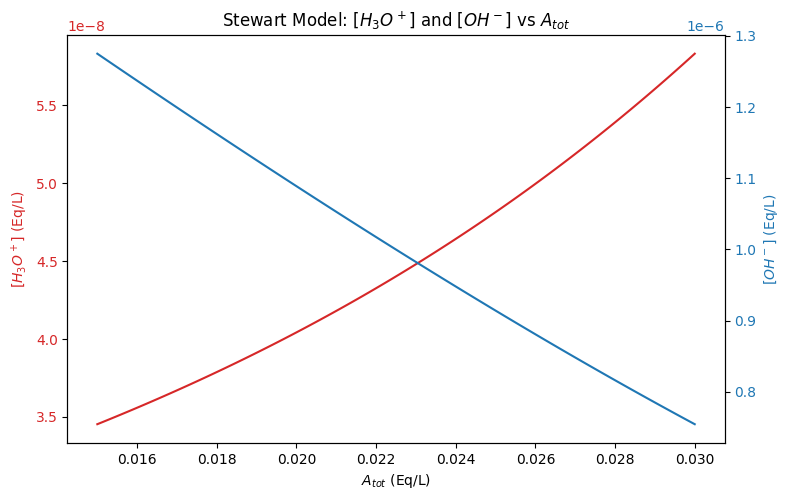

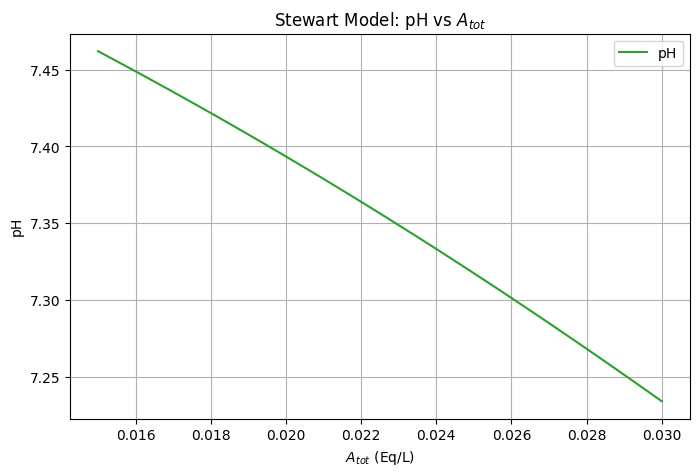

In [9]:
# --- Section 2: Vary A_tot ---
SID = 42e-3   # Eq/L (42 mEq/L)
pCO2 = 40     # mmHg
A_tot_values = np.linspace(15e-3, 30e-3, 100)  # 15–30 mEq/L

H_initial = 4e-8  # near physiologic pH of 7.4

H3O_values, OH_values, pH_values = [], [], []
for A_tot in A_tot_values:
    H_solution, = fsolve(stewart_quartic, H_initial, args=(SID, pCO2, A_tot))
    OH_solution = K_w / H_solution
    pH = -np.log10(H_solution)
    H3O_values.append(H_solution)
    OH_values.append(OH_solution)
    pH_values.append(pH)

# Plot: [H3O+] & [OH-] vs A_tot
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(A_tot_values, H3O_values, color='tab:red', label='$[H_3O^+]$')
ax1.set_xlabel('$A_{tot}$ (Eq/L)')
ax1.set_ylabel('$[H_3O^+]$ (Eq/L)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2 = ax1.twinx()
ax2.plot(A_tot_values, OH_values, color='tab:blue', label='$[OH^-]$')
ax2.set_ylabel('$[OH^-]$ (Eq/L)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
fig.tight_layout()
plt.title("Stewart Model: $[H_3O^+]$ and $[OH^-]$ vs $A_{tot}$")
plt.show()

# Plot: pH vs A_tot
plt.figure(figsize=(8,5))
plt.plot(A_tot_values, pH_values, color='tab:green', label='pH')
plt.xlabel('$A_{tot}$ (Eq/L)')
plt.ylabel('pH')
plt.title("Stewart Model: pH vs $A_{tot}$")
plt.grid(True)
plt.legend()
plt.show()

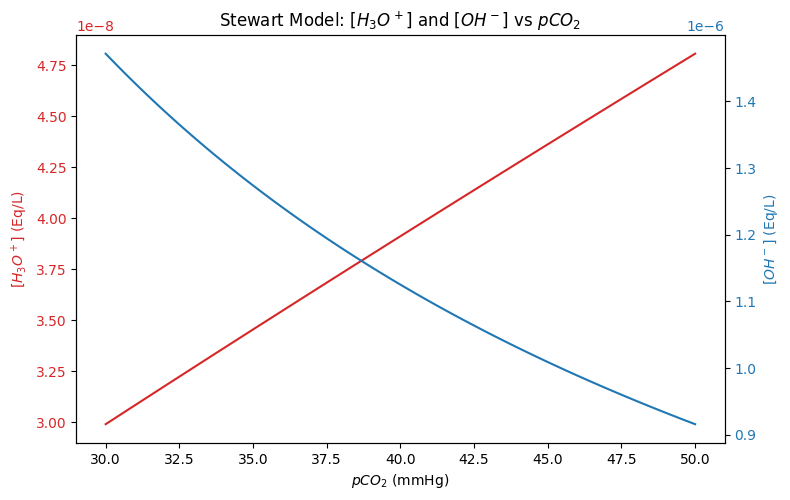

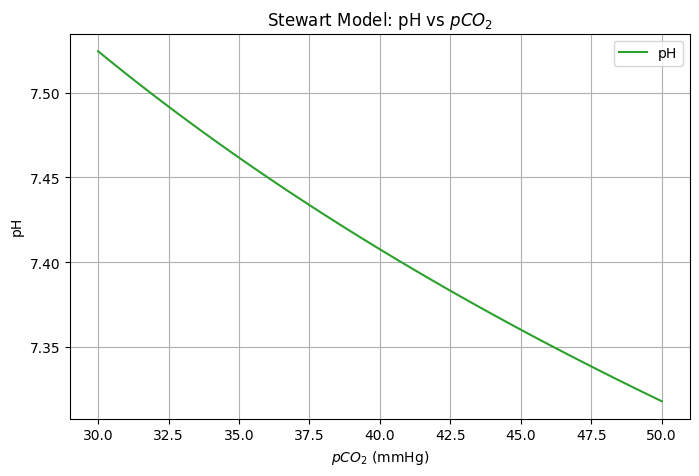

In [10]:
# --- Section 3: Vary pCO2 ---
SID = 42e-3   # Eq/L (42 mEq/L)
A_tot = 19e-3  # Eq/L (19 mEq/L)
pCO2_values = np.linspace(30, 50, 100)  # 30–50 mmHg

H_initial = 4e-8  # near physiologic pH of 7.4

H3O_values, OH_values, pH_values = [], [], []
for pCO2 in pCO2_values:
    H_solution, = fsolve(stewart_quartic, 1e-6, args=(SID, pCO2, A_tot))
    OH_solution = K_w / H_solution
    pH = -np.log10(H_solution)
    H3O_values.append(H_solution)
    OH_values.append(OH_solution)
    pH_values.append(pH)

# --- Plot: [H3O+] & [OH-] vs pCO2 ---
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(pCO2_values, H3O_values, color='tab:red', label='$[H_3O^+]$')
ax1.set_xlabel('$pCO_2$ (mmHg)')
ax1.set_ylabel('$[H_3O^+]$ (Eq/L)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2 = ax1.twinx()
ax2.plot(pCO2_values, OH_values, color='tab:blue', label='$[OH^-]$')
ax2.set_ylabel('$[OH^-]$ (Eq/L)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
fig.tight_layout()
plt.title("Stewart Model: $[H_3O^+]$ and $[OH^-]$ vs $pCO_2$")
plt.show()

# --- Plot: pH vs pCO2 ---
plt.figure(figsize=(8,5))
plt.plot(pCO2_values, pH_values, color='tab:green', label='pH')
plt.xlabel('$pCO_2$ (mmHg)')
plt.ylabel('pH')
plt.title("Stewart Model: pH vs $pCO_2$")
plt.grid(True)
plt.legend()
plt.show()

### Simulation 2: Balance of independent variables for keeping constant pH (human body context)

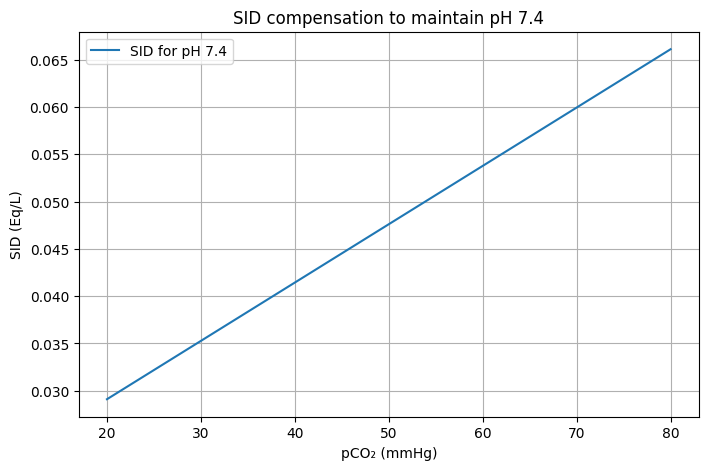

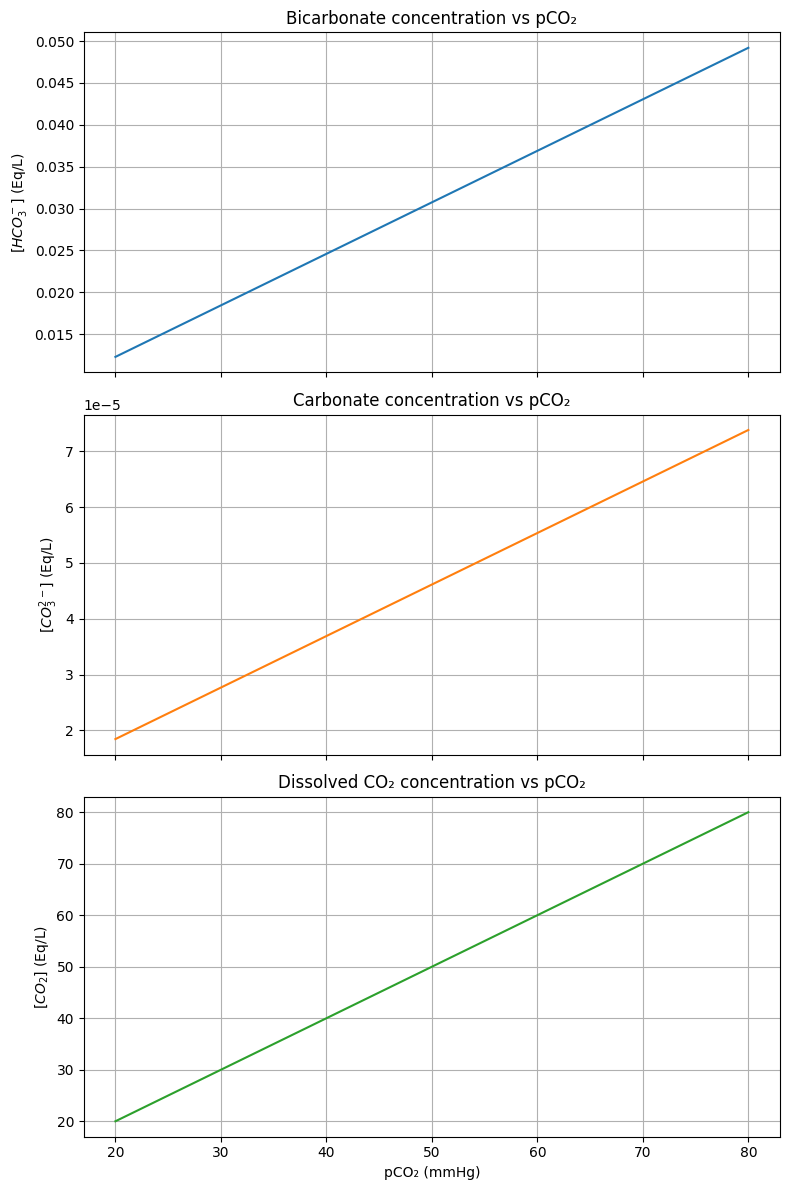

In [24]:
# --- Section 1: SID compensation for varying pCO2 to maintain pH = 7.4 ---

# fixed target pH
target_H = 4e-8       # equiv/L, pH 7.4
A_tot = 0.019         # equiv/L

# pCO2 sweep (mmHg)
pCO2_values = np.linspace(20, 80, 100)
SID_values = []

# Arrays to store CO2 buffering intermediates
HCO3_values = []
CO3_values = []
CO2_values = []

for pCO2 in pCO2_values:
    def SID_func(SID):
        H = target_H
        HCO3 = K_c * pCO2 / H
        CO3  = K_3 * HCO3 / H
        A_minus = A_tot * K_a / (K_a + H)
        OH = K_w / H
        return SID - (HCO3 + 2*CO3 + A_minus + OH - H)
    
    SID_solution, = fsolve(SID_func, 0.042)
    
    # compute intermediates for plotting
    HCO3 = K_c * pCO2 / target_H
    CO3  = K_3 * HCO3 / target_H
    CO2  = HCO3 * target_H / K_c
    
    SID_values.append(SID_solution)
    HCO3_values.append(HCO3)
    CO3_values.append(CO3)
    CO2_values.append(CO2)

plt.figure(figsize=(8,5))
plt.plot(pCO2_values, np.array(SID_values), color='tab:blue', label='SID for pH 7.4')
plt.xlabel('$pCO_2$ (mmHg)')
plt.ylabel('SID (Eq/L)')
plt.title('SID compensation to maintain pH 7.4')
plt.grid(True)
plt.legend()
plt.show()


# --- Plot intermediates against pCO2 ---
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# --- HCO3- ---
axs[0].plot(pCO2_values, np.array(HCO3_values), color='tab:blue')
axs[0].set_ylabel('$[HCO_3^-]$ (Eq/L)')
axs[0].set_title('Bicarbonate concentration vs $pCO_2$')
axs[0].grid(True)

# --- CO3^2- ---
axs[1].plot(pCO2_values, np.array(CO3_values), color='tab:orange')
axs[1].set_ylabel('$[CO_3^{2-}]$ (Eq/L)')
axs[1].set_title('Carbonate concentration vs $pCO_2$')
axs[1].grid(True)

# --- CO2 ---
axs[2].plot(pCO2_values, np.array(CO2_values), color='tab:green')
axs[2].set_xlabel('$pCO_2$ (mmHg)')
axs[2].set_ylabel('$[CO_2]$ (Eq/L)')
axs[2].set_title('Dissolved CO₂ concentration vs $pCO_2$')
axs[2].grid(True)

plt.tight_layout()
plt.show()

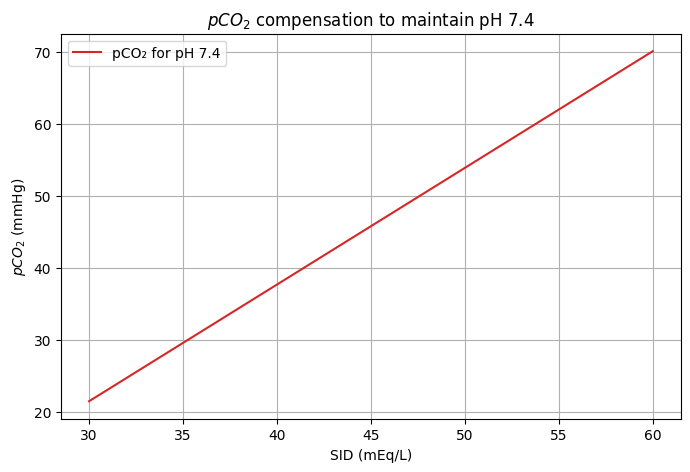

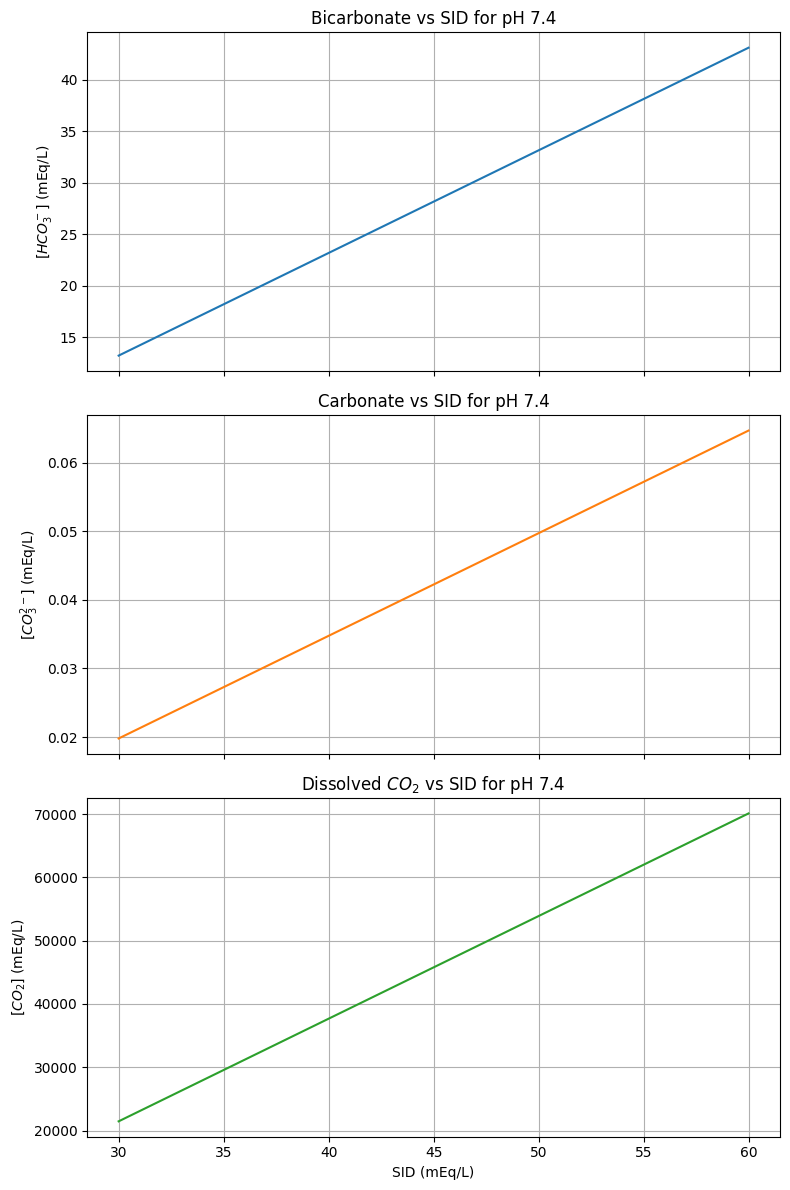

In [23]:
# --- Section 2: pCO2 compensation of changing SID to maintain pH = 7.4 ---

# fixed target pH
target_H = 4e-8       # equiv/L, pH 7.4
A_tot = 0.019         # equiv/L

SID_values = np.linspace(0.03, 0.06, 100)  # equiv/L
pCO2_values = []

# Arrays to store CO2 buffering intermediates
HCO3_values = []
CO3_values = []
CO2_values = []


for SID in SID_values:
    # Solve for pCO2 needed to maintain pH 7.4
    def pCO2_func(pCO2):
        H = target_H
        HCO3 = K_c * pCO2 / H
        CO3  = K_3 * HCO3 / H
        A_minus = A_tot * K_a / (K_a + H)
        OH = K_w / H
        return SID - (HCO3 + 2*CO3 + A_minus + OH - H)
    
    pCO2_solution, = fsolve(pCO2_func, 40)
    pCO2_values.append(pCO2_solution)
    
    # Compute intermediates
    HCO3 = K_c * pCO2_solution / target_H
    CO3  = K_3 * HCO3 / target_H
    CO2  = HCO3 * target_H / K_c
    
    HCO3_values.append(HCO3)
    CO3_values.append(CO3)
    CO2_values.append(CO2)

plt.figure(figsize=(8,5))
plt.plot(np.array(SID_values)*1000, pCO2_values, color='tab:red', label='$pCO_2$ for pH 7.4')
plt.xlabel('SID (mEq/L)')
plt.ylabel('$pCO_2$ (mmHg)')
plt.title('$pCO_2$ compensation to maintain pH 7.4')
plt.grid(True)
plt.legend()
plt.show()

# --- Plot intermediates against SID ---
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# HCO3-
axs[0].plot(np.array(SID_values)*1000, np.array(HCO3_values)*1000, color='tab:blue')
axs[0].set_ylabel('$[HCO_3^-]$ (mEq/L)')
axs[0].set_title('Bicarbonate vs SID for pH 7.4')
axs[0].grid(True)

# CO3^2-
axs[1].plot(np.array(SID_values)*1000, np.array(CO3_values)*1000, color='tab:orange')
axs[1].set_ylabel('$[CO_3^{2-}]$ (mEq/L)')
axs[1].set_title('Carbonate vs SID for pH 7.4')
axs[1].grid(True)

# CO2
axs[2].plot(np.array(SID_values)*1000, np.array(CO2_values)*1000, color='tab:green')
axs[2].set_xlabel('SID (mEq/L)')
axs[2].set_ylabel('$[CO_2]$ (mEq/L)')
axs[2].set_title('Dissolved $CO_2$ vs SID for pH 7.4')
axs[2].grid(True)

plt.tight_layout()
plt.show()

### Simulation 3: Attempting to independently moderate bicarbonate, $HCO_3^-$, and its effect on pH

In [31]:
# =========================
# Baseline conditions
# =========================

SID = 42e-3      # Eq/L
pCO2 = 40        # mmHg
A_tot = 19e-3    # Eq/L

H_initial = 4e-8

# Solve baseline
H_baseline, = fsolve(stewart_quartic, H_initial, args=(SID, pCO2, A_tot))
pH_baseline = -np.log10(H_baseline)

# Bicarbonate calculation
def calc_HCO3(H, pCO2):
    return (K_c * pCO2) / H

HCO3_baseline = calc_HCO3(H_baseline, pCO2)

print("Baseline state")
print(f"pH       = {pH_baseline:.3f}")
print(f"HCO3-    = {HCO3_baseline*1000:.2f} mEq/L")
print(f"pCO2     = {pCO2:.2f} mmHg")

Baseline state
pH       = 7.408
HCO3-    = 25.16 mEq/L
pCO2     = 40.00 mmHg


In [32]:
# =========================
# Force bicarbonate increase
# =========================

delta_HCO3 = 10e-3   # +10 mEq/L

HCO3_forced = HCO3_baseline + delta_HCO3

# Required pCO2 to satisfy equilibrium
pCO2_required = (HCO3_forced * H_baseline) / K_c

print("\nAttempted bicarbonate increase:")
print(f"Target HCO3- = {HCO3_forced*1000:.2f} mEq/L")
print(f"Required pCO2 = {pCO2_required:.2f} mmHg")


Attempted bicarbonate increase:
Target HCO3- = 35.16 mEq/L
Required pCO2 = 55.90 mmHg


In [40]:
# =========================
# Re-solve with new pCO2
# =========================

H_new, = fsolve(stewart_quartic, H_initial, args=(SID, pCO2_required, A_tot))
pH_new = -np.log10(H_new)

HCO3_new = calc_HCO3(H_new, pCO2_required)

print("\nNew equilibrium state")
print(f"pH       = {pH_new:.3f}")
print(f"HCO3-    = {HCO3_new*1000:.2f} mEq/L")
print(f"pCO2     = {pCO2_required:.2f} mmHg")


New equilibrium state
pH       = 7.274
HCO3-    = 25.84 mEq/L
pCO2     = 55.90 mmHg


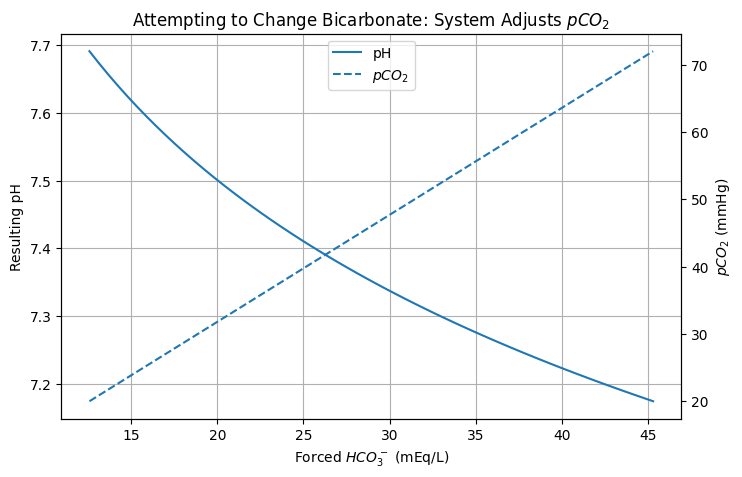

In [49]:
# =========================
# Sweep forced bicarbonate
# =========================

forced_range = np.linspace(HCO3_baseline*0.5, HCO3_baseline*1.8, 60)

pH_results = []
pCO2_results = []

for HCO3_target in forced_range:
    
    pCO2_req = (HCO3_target * H_baseline) / K_c
    
    H_sol, = fsolve(stewart_quartic, H_initial, args=(SID, pCO2_req, A_tot))
    
    pH_results.append(-np.log10(H_sol))
    pCO2_results.append(pCO2_req)


fig, ax1 = plt.subplots(figsize=(8,5))

# Left axis: pH
line1, = ax1.plot(np.array(forced_range)*1000, pH_results, label="pH")
ax1.set_xlabel("Forced $HCO_3^-$ (mEq/L)")
ax1.set_ylabel("Resulting pH")
ax1.grid(True)

# Right axis: pCO2
ax2 = ax1.twinx()
line2, = ax2.plot(np.array(forced_range)*1000, pCO2_results,
                  linestyle='--', label="$pCO_2$")
ax2.set_ylabel("$pCO_2$ (mmHg)")

# Combine legends from both axes
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center")

plt.title("Attempting to Change Bicarbonate: System Adjusts $pCO_2$")
plt.show()

In [38]:
# =========================
# Strong demonstration:
# Force bicarbonate while SID and pCO2 fixed
# =========================

SID = 42e-3
pCO2 = 40
A_tot = 19e-3

H_initial = 4e-8

# Baseline solve
H_baseline, = fsolve(stewart_quartic, H_initial, args=(SID, pCO2, A_tot))
pH_baseline = -np.log10(H_baseline)

def calc_HCO3(H, pCO2):
    return (K_c * pCO2) / H

HCO3_baseline = calc_HCO3(H_baseline, pCO2)

print("Baseline")
print(f"pH = {pH_baseline:.3f}")
print(f"HCO3- = {HCO3_baseline*1000:.2f} mEq/L")

Baseline
pH = 7.408
HCO3- = 25.16 mEq/L


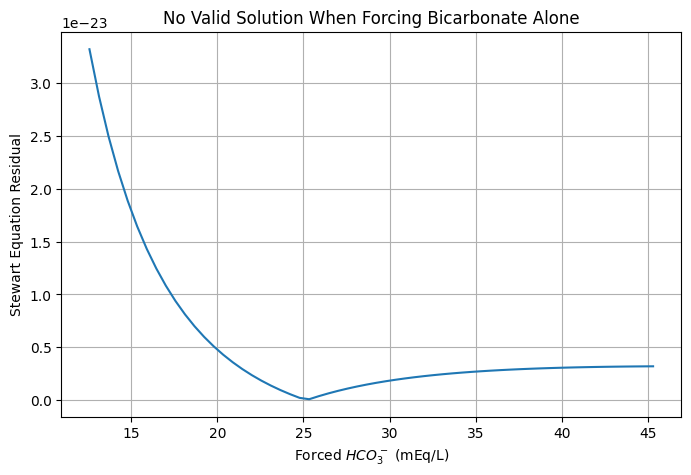

In [36]:
# Force bicarbonate to new value WITHOUT changing pCO2

forced_values = np.linspace(HCO3_baseline*0.5, HCO3_baseline*1.8, 60)

residuals = []
pH_forced = []

for HCO3_target in forced_values:
    
    # Forced hydrogen concentration from bicarbonate equation
    H_forced = (K_c * pCO2) / HCO3_target
    
    # Check Stewart quartic residual
    residual = stewart_quartic(H_forced, SID, pCO2, A_tot)
    
    residuals.append(abs(residual))
    pH_forced.append(-np.log10(H_forced))

plt.figure(figsize=(8,5))
plt.plot(forced_values*1000, residuals)
plt.xlabel("Forced $HCO_3^-$ (mEq/L)")
plt.ylabel("Stewart Equation Residual")
plt.title("No Valid Solution When Forcing Bicarbonate Alone")
#plt.yscale("log")
plt.grid(True)
plt.show()

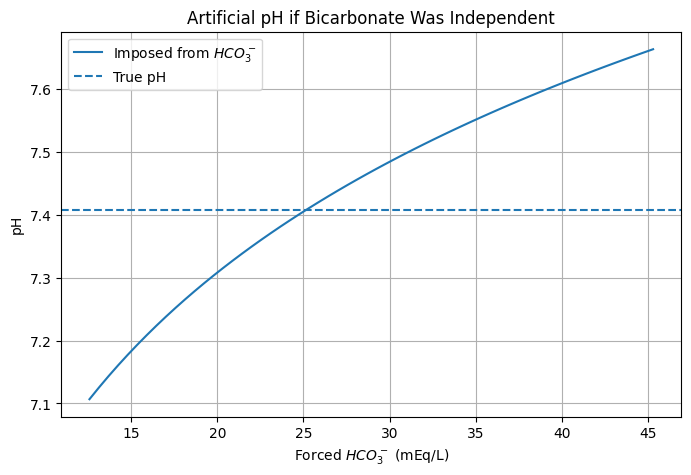

In [37]:
plt.figure(figsize=(8,5))
plt.plot(forced_values*1000, pH_forced, label="Imposed from $HCO_3^-$")
plt.axhline(pH_baseline, linestyle="--", label="True pH")
plt.xlabel("Forced $HCO_3^-$ (mEq/L)")
plt.ylabel("pH")
plt.title("Artificial pH if Bicarbonate Was Independent")
plt.legend()
plt.grid(True)
plt.show()